# Sampling Multi-Annotator Validation (Poin 15 Revisi)

Menjawab saran dosen penguji:
> *"Validasi multi annotator pseudo labelling — sampling 10 komentar per kelas = 30 data, dikirim ke 2-3 orang untuk validasi."*

**Asumsi desain** (silakan ubah `N_ANNOTATORS` / `SAME_SAMPLE_FOR_ALL` di bawah kalau beda):
- Sampling **10 komentar per kelas** (keluhan, saran, pujian) → **30 data**
- 30 data yang **sama** dikirim ke seluruh annotator (2-3 orang), supaya bisa dihitung *inter-annotator
  agreement* (Cohen's Kappa untuk 2 orang, Fleiss' Kappa untuk 3 orang) dan dibandingkan dengan
  pseudo-label (`label_pks`) hasil IndoBERT labeler
- File yang dikirim ke annotator **di-blind** (kolom `label_pks` dan `confidence` disembunyikan,
  urutan baris diacak) supaya tidak bias
- Ada 1 file "master/answer key" untuk kamu pegang sendiri (berisi id + pseudo-label asli), dipakai
  nanti untuk mencocokkan hasil validasi

**Output notebook ini:**
1. `annotator_sheet_blind.xlsx` — 1 sheet berisi 30 komentar teracak, tanpa label, siap dikirim ke ke-3 orang (masing-masing dapat salinan file yang sama, lalu isi kolom `label_annotator`)
2. `master_key_dengan_pseudo_label.xlsx` — untuk pegangan kamu, berisi id + label_pks + confidence
3. Cell tambahan di bagian akhir untuk **menghitung agreement** begitu hasil dari ke-3 annotator sudah kamu terima kembali

## 1. Setup & Load Data

In [2]:
import pandas as pd
import numpy as np

RANDOM_SEED = 42          # simpan angka ini di skripsi/lampiran biar sampling reproducible
N_PER_CLASS = 10           # 10 komentar per kelas
LABEL_COL = 'label_pks'    # kolom pseudo-label hasil IndoBERT labeler

PATH_DATA = "../data/processed/labelled_data_baru.csv"  # sesuaikan path

df = pd.read_csv(PATH_DATA)
print("Jumlah baris:", len(df))
print(df[LABEL_COL].value_counts())
df.head(3)

Jumlah baris: 61628
label_pks
keluhan    38125
pujian     12024
saran      11479
Name: count, dtype: int64


,id,timestamp,ownerUsername,text,likesCount,postUrl,commentUrl,source_file,label_pks,confidence
0,18131249071561283,2026-04-23 10:43:24+00:00,secretariat_irwn_999,"Dipikir dari sisi manapun, miliar ??? Buat apl...",4524,https://www.instagram.com/reel/DXd-RSckWCU/,https://www.instagram.com/reel/DXd-RSckWCU/?co...,dataset_instagram_20260525_132650.csv,keluhan,0.9908
1,18049919705732880,2026-04-23 13:30:10+00:00,peterkarundeng,SETIAP DEBUG MELEDAK 🤣 NGAKAK BANGETTT AMPUNNN...,2735,https://www.instagram.com/reel/DXd-RSckWCU/,https://www.instagram.com/reel/DXd-RSckWCU/?co...,dataset_instagram_20260525_132650.csv,keluhan,0.9868
2,18191321884373494,2026-05-24 00:24:25+00:00,aabahwarung,"Lolololololooolo abang nya yg ga paham, ga nya...",0,https://www.instagram.com/reel/DXd-RSckWCU/,https://www.instagram.com/reel/DXd-RSckWCU/?co...,dataset_instagram_20260525_132650.csv,keluhan,0.9873


## 2. Stratified Random Sampling (10 per kelas)

Pakai `random_state` tetap supaya hasil sampling bisa direproduksi kalau notebook dijalankan ulang
(penting untuk dilaporkan di metodologi skripsi).

In [36]:
import re

CONFIDENCE_MIN = 0.9
MIN_WORDS = 15   # ambang "agak panjang" -> minimal 5 kata bermakna, silakan sesuaikan

# Pola emoji (unicode range umum emoji)
EMOJI_PATTERN = re.compile(
    "["
    "\U0001F300-\U0001FAFF"
    "\U00002600-\U000027BF"
    "\U0001F1E6-\U0001F1FF"
    "\U00002B00-\U00002BFF"
    "]+", flags=re.UNICODE
)

def hitung_kata_bersih(text):
    text = str(text)
    text = EMOJI_PATTERN.sub(' ', text)          # buang emoji
    text = re.sub(r'[^\w\s]', ' ', text)          # buang tanda baca/simbol
    text = re.sub(r'\s+', ' ', text).strip()      # rapikan spasi
    return len(text.split()) if text else 0

df['word_count'] = df['text'].apply(hitung_kata_bersih)

df_filtered = df[
    (df['confidence'] > CONFIDENCE_MIN) &
    (df['word_count'] >= MIN_WORDS)
].copy()

print(f"Data awal: {len(df)}")
print(f"-> setelah filter confidence > {CONFIDENCE_MIN} dan word_count >= {MIN_WORDS}: {len(df_filtered)}")
print(df_filtered.groupby(LABEL_COL)['confidence'].describe())

Data awal: 61628
-> setelah filter confidence > 0.9 dan word_count >= 15: 11499
             count      mean       std     min     25%     50%     75%     max
label_pks                                                                     
keluhan    10117.0  0.974697  0.020866  0.9001  0.9685  0.9830  0.9891  0.9940
pujian       329.0  0.967539  0.024596  0.9014  0.9548  0.9753  0.9883  0.9948
saran       1053.0  0.944666  0.020592  0.9001  0.9280  0.9479  0.9631  0.9765


In [37]:
sampled_parts = []
for label_value, group in df_filtered.groupby(LABEL_COL):
    n_take = min(N_PER_CLASS, len(group))
    if n_take < N_PER_CLASS:
        print(f"[PERINGATAN] kelas '{label_value}' cuma {len(group)} data lolos filter (< {N_PER_CLASS})")
    sampled_parts.append(group.sample(n=n_take, random_state=RANDOM_SEED))

sample_df = pd.concat(sampled_parts, ignore_index=True)
sample_df[[LABEL_COL, 'text', 'confidence', 'word_count']]

,label_pks,text,confidence,word_count
0,keluhan,aku lihat gedung mbg sakit hati bgt kenapa hal...,0.9890,23
1,keluhan,"Bukan RSnya yang salah, tapi sistem BPJSnya. K...",0.9855,69
2,keluhan,giliran kasppg MW d angkat JD PNS giliran guru...,0.9903,30
3,keluhan,"ka mau tanya, log in Mjkn tpi nomer verifikasi...",0.9538,21
4,keluhan,kepada yth kenapa sekarang peraturan nya makin...,0.9722,90
5,keluhan,coretax itu paling parah design tampilannya ma...,0.9817,15
6,keluhan,Sy sekeluarga bpjs mandiri tp entah knp tiba b...,0.9834,17
7,keluhan,milik ortuku mandiri bayar auto debit aja tiba...,0.9792,19
8,keluhan,"Gw yg bayar pajak, gw yg ribet kocak. Harusnya...",0.9933,20
9,keluhan,Respect setinggi-tingginya untuk Bang Uya Kuya...,0.9154,22


## 3. Buat Master Key (untuk kamu pegang sendiri)

Berisi id, teks, pseudo-label asli, dan confidence — dipakai nanti untuk menghitung
agreement antara annotator vs pseudo-label.

In [38]:
master_key = sample_df[['id', 'text', LABEL_COL, 'confidence']].copy()
master_key = master_key.rename(columns={LABEL_COL: 'pseudo_label'})
master_key.to_excel('../outputs/docs/master_key_dengan_pseudo_label.xlsx', index=False)
master_key

,id,text,pseudo_label,confidence
0,7641476678904529665,aku lihat gedung mbg sakit hati bgt kenapa hal...,keluhan,0.9890
1,17963791020118446,"Bukan RSnya yang salah, tapi sistem BPJSnya. K...",keluhan,0.9855
2,7641479300713759505,giliran kasppg MW d angkat JD PNS giliran guru...,keluhan,0.9903
3,7558340139249828615,"ka mau tanya, log in Mjkn tpi nomer verifikasi...",keluhan,0.9538
4,7568716493711393544,kepada yth kenapa sekarang peraturan nya makin...,keluhan,0.9722
5,7621669004205523728,coretax itu paling parah design tampilannya ma...,keluhan,0.9817
6,18071056159886422,Sy sekeluarga bpjs mandiri tp entah knp tiba b...,keluhan,0.9834
7,7604114928489120533,milik ortuku mandiri bayar auto debit aja tiba...,keluhan,0.9792
8,18069929315558637,"Gw yg bayar pajak, gw yg ribet kocak. Harusnya...",keluhan,0.9933
9,18128336503517803,Respect setinggi-tingginya untuk Bang Uya Kuya...,keluhan,0.9154


## 4. Buat Lembar Blind untuk Annotator

- Kolom label & confidence **dihapus**
- Urutan baris **diacak ulang** (seed berbeda dari sampling supaya urutan kelas tidak mudah ditebak pola-nya)
- Tambah kolom kosong `label_annotator` (annotator isi salah satu: `keluhan` / `saran` / `pujian`) dan
  kolom `catatan` (opsional, kalau annotator ragu-ragu)

In [39]:
blind_sheet = sample_df[['id', 'text']].copy()
blind_sheet = blind_sheet.sample(frac=1, random_state=99).reset_index(drop=True)  # acak urutan
blind_sheet['label_annotator'] = ''   # diisi manual oleh annotator: keluhan / saran / pujian
blind_sheet['catatan'] = ''           # opsional

blind_sheet.to_excel('../outputs/docs/annotator_sheet_blind.xlsx', index=False)
print(f"Tersimpan -> outputs/docs/annotator_sheet_blind.xlsx ({len(blind_sheet)} baris)")
print("Kirim file ini (copy sebanyak jumlah annotator) ke masing-masing annotator.")
blind_sheet.head()

Tersimpan -> outputs/docs/annotator_sheet_blind.xlsx (30 baris)
Kirim file ini (copy sebanyak jumlah annotator) ke masing-masing annotator.


,id,text,label_annotator,catatan
0,7588698595286942471,saran si pak. MBG jangan terlalu banyak beli d...,,
1,17950568085092227,Min kalau suami tidak kerja dan npwp non-aktif...,,
2,17844293364564335,"Aku dah punya dari masih gadis ,,tapi baru di ...",,
3,7556268311882564360,mantap pak Purbaya 👍👍👍👍.... lanjut pak benahi ...,,
4,18101771695976296,kalopun beliau berobat pake bpjs ->pelayanan n...,,


> **Petunjuk untuk annotator (bisa ditempel di sheet ke-2 file Excel / email pengantar):**
> 1. Baca tiap komentar di kolom `text`
> 2. Isi kolom `label_annotator` dengan salah satu: `keluhan`, `saran`, atau `pujian`
>    - **Keluhan**: mengeluhkan/mengkritik masalah pada layanan
>    - **Saran**: memberi masukan/usulan perbaikan
>    - **Pujian**: memberi apresiasi/pujian positif
> 3. Kolom `catatan` boleh dikosongkan, isi kalau ada komentar yang ambigu/susah dikategorikan
> 4. Jangan diskusi dulu dengan annotator lain sebelum semua selesai mengisi (supaya independen)

## 5. (Setelah hasil dari 3 annotator kembali) — Gabungkan & Hitung Agreement

Jalankan bagian ini **setelah** ke-3 file Excel annotator sudah diisi dan dikembalikan.
Simpan masing-masing sebagai `annotator1_hasil.xlsx`, `annotator2_hasil.xlsx`, `annotator3_hasil.xlsx`
(atau sesuaikan nama file di cell berikutnya).

### 5a. Load Hasil Annotator (dengan penanganan kasus di luar skema 3 kelas)

Dua kasus yang perlu ditangani berbeda dari "label terisi normal":
- **Diisi tapi di luar skema** — annotator menulis label yang bukan `keluhan`/`saran`/`pujian`
  (mis. `"pertanyaan"`) langsung di kolom `label_annotator`
- **`label_annotator` kosong, tapi `catatan` diisi** — biasanya berarti annotator sengaja tidak
  memilih salah satu dari 3 kelas dan menjelaskan alasannya di catatan (mis. "ini pertanyaan, bukan
  keluhan/saran/pujian")
- **Kosong tanpa keterangan sama sekali** — kemungkinan besar annotator lupa mengisi, ini beda
  dengan dua kasus di atas dan sebaiknya dilaporkan terpisah (bukan diam-diam digabung ke "di luar skema")

Baris dengan status selain `'terisi'` akan diberi nilai `NaN` pada kolom label efektifnya, sehingga
otomatis tidak ikut dihitung Cohen's/Fleiss' Kappa (lewat `dropna()`), tapi tetap tercatat di tabel
`combined` untuk dilaporkan sebagai temuan kualitatif di skripsi.

In [40]:
VALID_LABELS = ['keluhan', 'saran', 'pujian']

# Ganti dengan path file hasil isian tiap annotator
PATH_ANNOTATOR_FILES = {
    'annotator_1': '../outputs/docs/annotator_sheet_blind_arfani.xlsx',
    'annotator_2': '../outputs/docs/annotator_sheet_blind_fauzan.xlsx',
    'annotator_3': '../outputs/docs/annotator_sheet_blind_mirna.xlsx',
}

def tentukan_status(label_raw, catatan_raw):
    label_filled = pd.notna(label_raw) and str(label_raw).strip() != ''
    note_filled = pd.notna(catatan_raw) and str(catatan_raw).strip() != ''
    label_clean = str(label_raw).strip().lower() if label_filled else None

    if label_filled and label_clean in VALID_LABELS:
        return 'terisi', label_clean
    elif label_filled and label_clean not in VALID_LABELS:
        return 'diluar_skema (label tidak baku)', np.nan
    elif not label_filled and note_filled:
        return 'diluar_skema (via catatan)', np.nan
    else:
        return 'kosong_tanpa_keterangan', np.nan

annot_dfs = {}
for name, path in PATH_ANNOTATOR_FILES.items():
    try:
        raw = pd.read_excel(path)[['id', 'label_annotator', 'catatan']]
        status_list, label_list = [], []
        for _, r in raw.iterrows():
            status, label_clean = tentukan_status(r['label_annotator'], r['catatan'])
            status_list.append(status)
            label_list.append(label_clean)

        a = pd.DataFrame({
            'id': raw['id'],
            name: label_list,                       # label efektif -> dipakai untuk Kappa
            f'{name}_catatan': raw['catatan'],
            f'{name}_status': status_list,
        })
        annot_dfs[name] = a
        print(f"{name}: {len(a)} baris dimuat")
        print(a[f'{name}_status'].value_counts().to_string())
        print()
    except FileNotFoundError:
        print(f"[BELUM ADA] {path} -- lewati dulu, jalankan lagi kalau file sudah tersedia")

annotator_1: 30 baris dimuat
annotator_1_status
terisi                        25
diluar_skema (via catatan)     5

annotator_2: 30 baris dimuat
annotator_2_status
terisi    30

annotator_3: 30 baris dimuat
annotator_3_status
terisi                        26
diluar_skema (via catatan)     4



In [41]:
# Gabungkan semua hasil annotator + master key jadi satu tabel perbandingan
combined = master_key[['id', 'text', 'pseudo_label']].copy()
for name, a in annot_dfs.items():
    combined = combined.merge(a, on='id', how='left')

combined

,id,text,pseudo_label,annotator_1,annotator_1_catatan,annotator_1_status,annotator_2,annotator_2_catatan,annotator_2_status,annotator_3,annotator_3_catatan,annotator_3_status
0,7641476678904529665,aku lihat gedung mbg sakit hati bgt kenapa hal...,keluhan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,17963791020118446,"Bukan RSnya yang salah, tapi sistem BPJSnya. K...",keluhan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,7641479300713759505,giliran kasppg MW d angkat JD PNS giliran guru...,keluhan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,7558340139249828615,"ka mau tanya, log in Mjkn tpi nomer verifikasi...",keluhan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,7568716493711393544,kepada yth kenapa sekarang peraturan nya makin...,keluhan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,7621669004205523728,coretax itu paling parah design tampilannya ma...,keluhan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,18071056159886422,Sy sekeluarga bpjs mandiri tp entah knp tiba b...,keluhan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,7604114928489120533,milik ortuku mandiri bayar auto debit aja tiba...,keluhan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,18069929315558637,"Gw yg bayar pajak, gw yg ribet kocak. Harusnya...",keluhan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,18128336503517803,Respect setinggi-tingginya untuk Bang Uya Kuya...,keluhan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [45]:
def tentukan_status(label_raw, catatan_raw):
    label_filled = pd.notna(label_raw) and str(label_raw).strip() != ''
    note_filled = pd.notna(catatan_raw) and str(catatan_raw).strip() != ''
    label_clean = str(label_raw).strip().lower() if label_filled else None
    if label_filled and label_clean in VALID_LABELS:
        return 'terisi', label_clean
    elif label_filled and label_clean not in VALID_LABELS:
        return 'diluar_skema (label tidak baku)', np.nan
    elif not label_filled and note_filled:
        return 'diluar_skema (via catatan)', np.nan
    else:
        return 'kosong_tanpa_keterangan', np.nan

annot_dfs = {}
for name, path in PATH_ANNOTATOR_FILES.items():
    try:
        raw = pd.read_excel(path)[['text', 'label_annotator', 'catatan']]   # <- pakai text, bukan id
        status_list, label_list = [], []
        for _, r in raw.iterrows():
            status, label_clean = tentukan_status(r['label_annotator'], r['catatan'])
            status_list.append(status)
            label_list.append(label_clean)

        a = pd.DataFrame({
            'text': raw['text'],
            name: label_list,
            f'{name}_catatan': raw['catatan'],
            f'{name}_status': status_list,
        })
        annot_dfs[name] = a
        print(f"{name}: {len(a)} baris dimuat")
        print(a[f'{name}_status'].value_counts().to_string())
        print()
    except FileNotFoundError:
        print(f"[BELUM ADA] {path}")

# merge pakai 'text', bukan 'id'
combined = master_key[['id', 'text', 'pseudo_label']].copy()
for name, a in annot_dfs.items():
    combined = combined.merge(a, on='text', how='left')

combined

annotator_1: 30 baris dimuat
annotator_1_status
terisi                        25
diluar_skema (via catatan)     5

annotator_2: 30 baris dimuat
annotator_2_status
terisi    30

annotator_3: 30 baris dimuat
annotator_3_status
terisi                        26
diluar_skema (via catatan)     4



,id,text,pseudo_label,annotator_1,annotator_1_catatan,annotator_1_status,annotator_2,annotator_2_catatan,annotator_2_status,annotator_3,annotator_3_catatan,annotator_3_status
0,7641476678904529665,aku lihat gedung mbg sakit hati bgt kenapa hal...,keluhan,keluhan,NaN,terisi,keluhan,NaN,terisi,keluhan,NaN,terisi
1,17963791020118446,"Bukan RSnya yang salah, tapi sistem BPJSnya. K...",keluhan,saran,NaN,terisi,keluhan,NaN,terisi,keluhan,NaN,terisi
2,7641479300713759505,giliran kasppg MW d angkat JD PNS giliran guru...,keluhan,saran,NaN,terisi,keluhan,NaN,terisi,keluhan,NaN,terisi
3,7558340139249828615,"ka mau tanya, log in Mjkn tpi nomer verifikasi...",keluhan,NaN,pertanyaan,diluar_skema (via catatan),keluhan,pertanyaan,terisi,keluhan,Disertai dengan pertanyaan,terisi
4,7568716493711393544,kepada yth kenapa sekarang peraturan nya makin...,keluhan,keluhan,NaN,terisi,keluhan,NaN,terisi,keluhan,Disertai dengan pertanyaan,terisi
5,7621669004205523728,coretax itu paling parah design tampilannya ma...,keluhan,keluhan,NaN,terisi,keluhan,NaN,terisi,keluhan,NaN,terisi
6,18071056159886422,Sy sekeluarga bpjs mandiri tp entah knp tiba b...,keluhan,keluhan,NaN,terisi,keluhan,NaN,terisi,keluhan,NaN,terisi
7,7604114928489120533,milik ortuku mandiri bayar auto debit aja tiba...,keluhan,keluhan,NaN,terisi,keluhan,satire,terisi,keluhan,NaN,terisi
8,18069929315558637,"Gw yg bayar pajak, gw yg ribet kocak. Harusnya...",keluhan,keluhan,NaN,terisi,keluhan,NaN,terisi,keluhan,NaN,terisi
9,18128336503517803,Respect setinggi-tingginya untuk Bang Uya Kuya...,keluhan,pujian,NaN,terisi,pujian,NaN,terisi,pujian,NaN,terisi


### 5b. Rekap Status per Annotator (untuk lampiran/pembahasan Bab IV)

Tabel ini menunjukkan berapa banyak data per annotator yang terisi normal vs di luar skema vs
benar-benar kosong -- ini yang sebaiknya kamu lampirkan/ceritakan di skripsi, bukan cuma angka Kappa-nya saja.

In [46]:
status_cols = [f'{name}_status' for name in annot_dfs.keys() if f'{name}_status' in combined.columns]
rekap_status = combined[status_cols].apply(pd.Series.value_counts).fillna(0).astype(int)
rekap_status

,annotator_1_status,annotator_2_status,annotator_3_status
diluar_skema (via catatan),5,0,4
terisi,25,30,26


In [47]:
# Lihat detail baris yang di luar skema / kosong tanpa keterangan -- kandidat temuan kualitatif
mask_perlu_dicek = combined[status_cols].apply(lambda col: col != 'terisi').any(axis=1)
kolom_lihat = ['id', 'text', 'pseudo_label'] + list(annot_dfs.keys()) + status_cols
display(combined.loc[mask_perlu_dicek, kolom_lihat])

,id,text,pseudo_label,annotator_1,annotator_2,annotator_3,annotator_1_status,annotator_2_status,annotator_3_status
3,7558340139249828615,"ka mau tanya, log in Mjkn tpi nomer verifikasi...",keluhan,NaN,keluhan,keluhan,diluar_skema (via catatan),terisi,terisi
20,7629486961649156884,"dok, sebenarnya boleh ga sih dok, klu anak dem...",saran,NaN,saran,NaN,diluar_skema (via catatan),terisi,diluar_skema (via catatan)
22,7633627480130437908,mau bertanya min. ini sudah sesuai dengan SOP ...,saran,NaN,keluhan,NaN,diluar_skema (via catatan),terisi,diluar_skema (via catatan)
24,17950568085092227,Min kalau suami tidak kerja dan npwp non-aktif...,saran,NaN,saran,NaN,diluar_skema (via catatan),terisi,diluar_skema (via catatan)
28,7546503363283501832,"mo nanya, aku dari bpjs gratis pengen beralih ...",saran,NaN,keluhan,NaN,diluar_skema (via catatan),terisi,diluar_skema (via catatan)


In [48]:
# Persentase kesepakatan sederhana (percent agreement) tiap annotator vs pseudo-label
# (otomatis hanya menghitung baris berstatus 'terisi', karena baris lain bernilai NaN)
for name in annot_dfs.keys():
    valid = combined[['pseudo_label', name]].dropna()
    agree = (valid[name] == valid['pseudo_label']).mean() * 100
    print(f"Agreement {name} vs pseudo-label: {agree:.2f}%  (dihitung dari n={len(valid)} data berstatus 'terisi')")

Agreement annotator_1 vs pseudo-label: 76.00%  (dihitung dari n=25 data berstatus 'terisi')
Agreement annotator_2 vs pseudo-label: 76.67%  (dihitung dari n=30 data berstatus 'terisi')
Agreement annotator_3 vs pseudo-label: 80.77%  (dihitung dari n=26 data berstatus 'terisi')


### Cohen's Kappa (2 annotator) / Fleiss' Kappa (3+ annotator, atau vs pseudo-label)

`scikit-learn` sudah cukup untuk Cohen's Kappa antar 2 kolom mana pun (annotator-annotator atau
annotator-pseudo_label). Untuk Fleiss' Kappa (>2 rater sekaligus) dipakai implementasi manual di bawah.

Karena baris berstatus selain `'terisi'` sudah bernilai `NaN` di kolom label efektif, `dropna()` di
bawah ini otomatis mengeluarkan baris tersebut dari perhitungan Kappa -- jadi Kappa yang dihasilkan
murni mengukur kesepakatan pada data yang memang sepadan (dalam skema 3 kelas).

In [49]:
from sklearn.metrics import cohen_kappa_score
from itertools import combinations

rater_cols = ['pseudo_label'] + list(annot_dfs.keys())
rater_cols = [c for c in rater_cols if c in combined.columns and combined[c].notna().any()]

print("Cohen's Kappa antar pasangan rater (hanya data berstatus 'terisi'):")
for a, b in combinations(rater_cols, 2):
    valid = combined[[a, b]].dropna()
    if len(valid) > 1:
        k = cohen_kappa_score(valid[a], valid[b])
        print(f"  {a} vs {b}: kappa = {k:.3f}  (n={len(valid)})")
    else:
        print(f"  {a} vs {b}: data valid terlalu sedikit (n={len(valid)}) untuk dihitung")

Cohen's Kappa antar pasangan rater (hanya data berstatus 'terisi'):
  pseudo_label vs annotator_1: kappa = 0.632  (n=25)
  pseudo_label vs annotator_2: kappa = 0.650  (n=30)
  pseudo_label vs annotator_3: kappa = 0.696  (n=26)
  annotator_1 vs annotator_2: kappa = 0.751  (n=25)
  annotator_1 vs annotator_3: kappa = 0.812  (n=25)
  annotator_2 vs annotator_3: kappa = 0.936  (n=26)


In [50]:
def fleiss_kappa(rating_matrix):
    """rating_matrix: array (n_items, n_categories) berisi jumlah rater yang memilih tiap kategori."""
    n_items, n_categories = rating_matrix.shape
    n_raters = rating_matrix.sum(axis=1)[0]

    p_j = rating_matrix.sum(axis=0) / (n_items * n_raters)
    P_i = ((rating_matrix ** 2).sum(axis=1) - n_raters) / (n_raters * (n_raters - 1))
    P_bar = P_i.mean()
    P_e = (p_j ** 2).sum()

    return (P_bar - P_e) / (1 - P_e)

rater_only_cols = [c for c in annot_dfs.keys() if c in combined.columns]
if len(rater_only_cols) >= 3:
    cats = VALID_LABELS
    counts = combined[rater_only_cols].apply(lambda row: [list(row).count(c) for c in cats], axis=1, result_type='expand')
    counts.columns = cats
    # hanya baris di mana SEMUA annotator berstatus 'terisi' (baris dgn NaN otomatis tersingkir)
    valid_rows = counts[counts.sum(axis=1) == len(rater_only_cols)]
    n_excluded = len(combined) - len(valid_rows)
    print(f"Baris dikeluarkan dari Fleiss' Kappa (di luar skema / kosong pada minimal 1 annotator): {n_excluded}")
    if len(valid_rows) > 0:
        fk = fleiss_kappa(valid_rows.values)
        print(f"Fleiss' Kappa (antar {len(rater_only_cols)} annotator, n={len(valid_rows)}): {fk:.3f}")
    else:
        print("Tidak ada baris yang lengkap 'terisi' di semua annotator -- Fleiss' Kappa tidak bisa dihitung.")
else:
    print("Fleiss' Kappa butuh minimal 3 kolom annotator terisi lengkap -- lengkapi dulu file hasil annotator.")

Baris dikeluarkan dari Fleiss' Kappa (di luar skema / kosong pada minimal 1 annotator): 5
Fleiss' Kappa (antar 3 annotator, n=25): 0.830


**Cara melaporkan temuan "di luar skema" di skripsi** (Bab IV, bagian validasi multi-annotator):

> *"Dari 30 data yang divalidasi oleh 3 annotator independen, sejumlah N data (Y%) ditandai oleh
> minimal satu annotator sebagai berada di luar skema klasifikasi tiga kelas (keluhan/saran/pujian) --
> misalnya dikategorikan sebagai 'pertanyaan'. Data tersebut dikeluarkan dari perhitungan Cohen's/Fleiss'
> Kappa karena tidak sepadan dengan ruang label pseudo-labelling, namun tetap dilaporkan sebagai temuan
> yang mengindikasikan keterbatasan taksonomi tiga kelas pada penelitian ini dan berpotensi menjadi
> arah penelitian lanjutan (mis. penambahan kelas 'pertanyaan' atau kelas 'lainnya')."*

Ambil angka N dan Y% langsung dari tabel `rekap_status` / hasil `mask_perlu_dicek` di atas.

**Panduan interpretasi Kappa (Landis & Koch, 1977)** — bisa dikutip di skripsi:
- < 0.00 : Poor
- 0.00–0.20 : Slight
- 0.21–0.40 : Fair
- 0.41–0.60 : Moderate
- 0.61–0.80 : Substantial
- 0.81–1.00 : Almost Perfect

Simpan tabel `combined` beserta nilai kappa di atas sebagai lampiran validasi multi-annotator di skripsi.

In [51]:
combined.to_excel('../outputs/docs/hasil_validasi_multi_annotator.xlsx', index=False)
print("Tersimpan -> outputs/docs/hasil_validasi_multi_annotator.xlsx")

Tersimpan -> outputs/docs/hasil_validasi_multi_annotator.xlsx


### Cohen's Kappa (2 annotator) / Fleiss' Kappa (3+ annotator, atau vs pseudo-label)

`scikit-learn` sudah cukup untuk Cohen's Kappa antar 2 kolom mana pun (annotator-annotator atau
annotator-pseudo_label). Untuk Fleiss' Kappa (>2 rater sekaligus) dipakai implementasi manual di bawah.

Karena baris berstatus selain `'terisi'` sudah bernilai `NaN` di kolom label efektif, `dropna()` di
bawah ini otomatis mengeluarkan baris tersebut dari perhitungan Kappa -- jadi Kappa yang dihasilkan
murni mengukur kesepakatan pada data yang memang sepadan (dalam skema 3 kelas).

In [52]:
from sklearn.metrics import cohen_kappa_score
from itertools import combinations

def kategori_landis_koch(k):
    if k < 0:
        return 'Poor'
    elif k <= 0.20:
        return 'Slight'
    elif k <= 0.40:
        return 'Fair'
    elif k <= 0.60:
        return 'Moderate'
    elif k <= 0.80:
        return 'Substantial'
    else:
        return 'Almost Perfect'

rater_cols = ['pseudo_label'] + list(annot_dfs.keys())
rater_cols = [c for c in rater_cols if c in combined.columns and combined[c].notna().any()]

kappa_results = []  # dipakai lagi di tabel ringkasan (bagian 5c)
print("Cohen's Kappa antar pasangan rater (hanya data berstatus 'terisi'):")
for a, b in combinations(rater_cols, 2):
    valid = combined[[a, b]].dropna()
    if len(valid) > 1:
        k = cohen_kappa_score(valid[a], valid[b])
        kappa_results.append({'Pasangan': f'{a} vs {b}', 'Kappa': round(k, 3), 'n': len(valid),
                               'Interpretasi': kategori_landis_koch(k)})
        print(f"  {a} vs {b}: kappa = {k:.3f}  (n={len(valid)})")
    else:
        print(f"  {a} vs {b}: data valid terlalu sedikit (n={len(valid)}) untuk dihitung")

Cohen's Kappa antar pasangan rater (hanya data berstatus 'terisi'):
  pseudo_label vs annotator_1: kappa = 0.632  (n=25)
  pseudo_label vs annotator_2: kappa = 0.650  (n=30)
  pseudo_label vs annotator_3: kappa = 0.696  (n=26)
  annotator_1 vs annotator_2: kappa = 0.751  (n=25)
  annotator_1 vs annotator_3: kappa = 0.812  (n=25)
  annotator_2 vs annotator_3: kappa = 0.936  (n=26)


In [53]:
def fleiss_kappa(rating_matrix):
    """rating_matrix: array (n_items, n_categories) berisi jumlah rater yang memilih tiap kategori."""
    n_items, n_categories = rating_matrix.shape
    n_raters = rating_matrix.sum(axis=1)[0]

    p_j = rating_matrix.sum(axis=0) / (n_items * n_raters)
    P_i = ((rating_matrix ** 2).sum(axis=1) - n_raters) / (n_raters * (n_raters - 1))
    P_bar = P_i.mean()
    P_e = (p_j ** 2).sum()

    return (P_bar - P_e) / (1 - P_e)

rater_only_cols = [c for c in annot_dfs.keys() if c in combined.columns]
n_excluded_fleiss = 0
if len(rater_only_cols) >= 3:
    cats = VALID_LABELS
    counts = combined[rater_only_cols].apply(lambda row: [list(row).count(c) for c in cats], axis=1, result_type='expand')
    counts.columns = cats
    # hanya baris di mana SEMUA annotator berstatus 'terisi' (baris dgn NaN otomatis tersingkir)
    valid_rows = counts[counts.sum(axis=1) == len(rater_only_cols)]
    n_excluded_fleiss = len(combined) - len(valid_rows)
    print(f"Baris dikeluarkan dari Fleiss' Kappa (di luar skema / kosong pada minimal 1 annotator): {n_excluded_fleiss}")
    if len(valid_rows) > 0:
        fk = fleiss_kappa(valid_rows.values)
        print(f"Fleiss' Kappa (antar {len(rater_only_cols)} annotator, n={len(valid_rows)}): {fk:.3f}")
        kappa_results.append({'Pasangan': f"Fleiss' Kappa ({len(rater_only_cols)} annotator)",
                               'Kappa': round(fk, 3), 'n': len(valid_rows),
                               'Interpretasi': kategori_landis_koch(fk)})
    else:
        print("Tidak ada baris yang lengkap 'terisi' di semua annotator -- Fleiss' Kappa tidak bisa dihitung.")
else:
    print("Fleiss' Kappa butuh minimal 3 kolom annotator terisi lengkap -- lengkapi dulu file hasil annotator.")

Baris dikeluarkan dari Fleiss' Kappa (di luar skema / kosong pada minimal 1 annotator): 5
Fleiss' Kappa (antar 3 annotator, n=25): 0.830


### 5c. Tabel Ringkasan Kappa (siap tempel ke Lampiran Skripsi)

In [54]:
kappa_summary = pd.DataFrame(kappa_results)
kappa_summary.to_excel('../outputs/docs/ringkasan_kappa_validasi.xlsx', index=False)
print("Tersimpan -> outputs/docs/ringkasan_kappa_validasi.xlsx")
kappa_summary

Tersimpan -> outputs/docs/ringkasan_kappa_validasi.xlsx


,Pasangan,Kappa,n,Interpretasi
0,pseudo_label vs annotator_1,0.632,25,Substantial
1,pseudo_label vs annotator_2,0.650,30,Substantial
2,pseudo_label vs annotator_3,0.696,26,Substantial
3,annotator_1 vs annotator_2,0.751,25,Substantial
4,annotator_1 vs annotator_3,0.812,25,Almost Perfect
5,annotator_2 vs annotator_3,0.936,26,Almost Perfect
6,Fleiss' Kappa (3 annotator),0.830,25,Almost Perfect


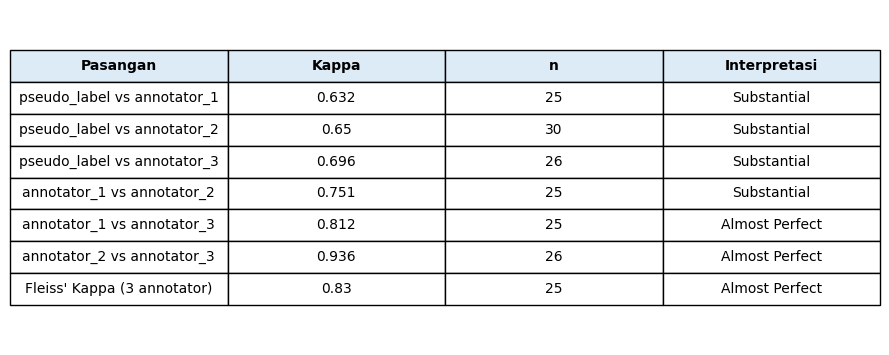

Tersimpan -> outputs/figures/tabel_ringkasan_kappa.png


In [55]:
import matplotlib.pyplot as plt
# Render tabel jadi gambar (.png) -- praktis untuk ditempel langsung sebagai figur/lampiran di Word
fig, ax = plt.subplots(figsize=(9, 0.5 + 0.45 * len(kappa_summary)))
ax.axis('off')
tbl = ax.table(cellText=kappa_summary.values, colLabels=kappa_summary.columns,
                cellLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.6)

for j, col in enumerate(kappa_summary.columns):
    tbl[0, j].set_text_props(weight='bold')
    tbl[0, j].set_facecolor('#DDEBF7')

plt.tight_layout()
plt.savefig('../outputs/figures/tabel_ringkasan_kappa.png', dpi=200, bbox_inches='tight')
plt.show()
print("Tersimpan -> outputs/figures/tabel_ringkasan_kappa.png")

### 5d. Detail Baris yang Tidak Sepakat (pseudo_label vs annotator)

Untuk pembahasan kualitatif di Bab IV: komentar mana saja yang pseudo-label-nya berbeda dari
penilaian annotator manusia, dan pola apa yang terlihat (mis. sarkasme, konteks implisit, dsb).

In [56]:
disagree_rows = []
for name in annot_dfs.keys():
    valid = combined[['id', 'text', 'pseudo_label', name]].dropna(subset=['pseudo_label', name])
    tidak_sepakat = valid[valid['pseudo_label'] != valid[name]].copy()
    tidak_sepakat['annotator'] = name
    tidak_sepakat = tidak_sepakat.rename(columns={name: 'label_annotator'})
    disagree_rows.append(tidak_sepakat[['id', 'text', 'pseudo_label', 'annotator', 'label_annotator']])

disagreement_df = pd.concat(disagree_rows, ignore_index=True) if disagree_rows else pd.DataFrame()
print(f"Total baris tidak sepakat (pseudo_label vs annotator manapun): {len(disagreement_df)}")
disagreement_df

Total baris tidak sepakat (pseudo_label vs annotator manapun): 18


,id,text,pseudo_label,annotator,label_annotator
0,17963791020118446,"Bukan RSnya yang salah, tapi sistem BPJSnya. K...",keluhan,annotator_1,saran
1,7641479300713759505,giliran kasppg MW d angkat JD PNS giliran guru...,keluhan,annotator_1,saran
2,18128336503517803,Respect setinggi-tingginya untuk Bang Uya Kuya...,keluhan,annotator_1,pujian
3,17945481252145833,dipangkas semua hari jg gpp kok pak km ikhlas....,pujian,annotator_1,keluhan
4,18101771695976296,kalopun beliau berobat pake bpjs ->pelayanan n...,saran,annotator_1,keluhan
5,7585458298318291713,AQ lupa email apa harus ke kantor pajak yg per...,saran,annotator_1,keluhan
6,18128336503517803,Respect setinggi-tingginya untuk Bang Uya Kuya...,keluhan,annotator_2,pujian
7,17945481252145833,dipangkas semua hari jg gpp kok pak km ikhlas....,pujian,annotator_2,saran
8,18101771695976296,kalopun beliau berobat pake bpjs ->pelayanan n...,saran,annotator_2,keluhan
9,7633627480130437908,mau bertanya min. ini sudah sesuai dengan SOP ...,saran,annotator_2,keluhan


In [57]:
# Baris yang TIDAK disepakati pseudo_label oleh MAYORITAS annotator (>=2 dari 3) -- kandidat paling
# layak dibahas di skripsi, karena bukan cuma beda pendapat 1 orang tapi konsensus manusia vs model
if len(disagreement_df) > 0:
    rekap_disagreement = (
        disagreement_df.groupby(['id', 'text', 'pseudo_label'])
        .agg(jumlah_annotator_tidak_sepakat=('annotator', 'nunique'),
             label_annotator_diberikan=('label_annotator', lambda x: ', '.join(sorted(set(x)))))
        .reset_index()
        .sort_values('jumlah_annotator_tidak_sepakat', ascending=False)
    )
    rekap_disagreement.to_excel('../outputs/docs/detail_disagreement_pseudo_label.xlsx', index=False)
    print("Tersimpan -> outputs/docs/detail_disagreement_pseudo_label.xlsx")
    display(rekap_disagreement)
else:
    print("Tidak ada disagreement -- pseudo_label 100% sepakat dengan seluruh annotator pada data 'terisi'.")

Tersimpan -> outputs/docs/detail_disagreement_pseudo_label.xlsx


,id,text,pseudo_label,jumlah_annotator_tidak_sepakat,label_annotator_diberikan
0,17945481252145833,dipangkas semua hari jg gpp kok pak km ikhlas....,pujian,3,"keluhan, saran"
2,18101771695976296,kalopun beliau berobat pake bpjs ->pelayanan n...,saran,3,keluhan
3,18128336503517803,Respect setinggi-tingginya untuk Bang Uya Kuya...,keluhan,3,pujian
5,7585458298318291713,AQ lupa email apa harus ke kantor pajak yg per...,saran,3,keluhan
6,7595595257351701268,Yudhi Sadewa maaf pak ini bener bngt mohon di ...,saran,2,keluhan
4,7546503363283501832,"mo nanya, aku dari bpjs gratis pengen beralih ...",saran,1,keluhan
1,17963791020118446,"Bukan RSnya yang salah, tapi sistem BPJSnya. K...",keluhan,1,saran
7,7633627480130437908,mau bertanya min. ini sudah sesuai dengan SOP ...,saran,1,keluhan
8,7641479300713759505,giliran kasppg MW d angkat JD PNS giliran guru...,keluhan,1,saran


**Cara pakai untuk Bab IV:** ambil beberapa contoh dari `rekap_disagreement` yang
`jumlah_annotator_tidak_sepakat` bernilai 2 atau 3 (artinya mayoritas/semua annotator manusia
berbeda pendapat dengan pseudo-label), lalu bahas kualitatif -- misalnya apakah komentar tersebut
mengandung sarkasme, konteks yang perlu pengetahuan latar (mis. isu terkini terkait layanan), atau
memang berada di batas ambigu antar dua kelas (mis. keluhan yang disertai saran).

### Cara melaporkan temuan "di luar skema" di skripsi (Bab IV, bagian validasi multi-annotator):

> *"Dari 30 data yang divalidasi oleh 3 annotator independen, sejumlah N data (Y%) ditandai oleh
> minimal satu annotator sebagai berada di luar skema klasifikasi tiga kelas (keluhan/saran/pujian) --
> misalnya dikategorikan sebagai 'pertanyaan'. Data tersebut dikeluarkan dari perhitungan Cohen's/Fleiss'
> Kappa karena tidak sepadan dengan ruang label pseudo-labelling, namun tetap dilaporkan sebagai temuan
> yang mengindikasikan keterbatasan taksonomi tiga kelas pada penelitian ini dan berpotensi menjadi
> arah penelitian lanjutan (mis. penambahan kelas 'pertanyaan' atau kelas 'lainnya')."*

Ambil angka N dan Y% langsung dari tabel `rekap_status` / hasil `mask_perlu_dicek` di atas.

**Panduan interpretasi Kappa (Landis & Koch, 1977)** — bisa dikutip di skripsi:
- < 0.00 : Poor
- 0.00–0.20 : Slight
- 0.21–0.40 : Fair
- 0.41–0.60 : Moderate
- 0.61–0.80 : Substantial
- 0.81–1.00 : Almost Perfect

Simpan tabel `combined` beserta nilai kappa di atas sebagai lampiran validasi multi-annotator di skripsi.

In [58]:
combined.to_excel('../outputs/docs/hasil_validasi_multi_annotator.xlsx', index=False)
print("Tersimpan -> outputs/docs/hasil_validasi_multi_annotator.xlsx")

Tersimpan -> outputs/docs/hasil_validasi_multi_annotator.xlsx
